In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Quantum teleportation
* **Input** : An unknown qubit state $|\psi\rangle = a|0\rangle + b|1\rangle$ with Alice + Alice and Bob share entangled pair in state $|\beta_{00}\rangle$
* **Task**  : Teleport the state $|\psi\rangle$ to Bob
* **Pseudocode**
$$\begin{align*}
|\psi\rangle|\beta_{0}\rangle = &\frac{1}{\sqrt{2}}\left[a|0\rangle(|00\rangle + |11\rangle) + b|1\rangle(|00\rangle + |11\rangle)\right]\\
\xrightarrow{\text{Alice }CNOT(0,1)} &\frac{1}{\sqrt{2}}\left[a|0\rangle(|00\rangle + |11\rangle) + b|1\rangle(|10\rangle + |01\rangle)\right]\\
\xrightarrow{\text{Alice }H(0)} &\frac{1}{2}\left[a(|0\rangle + |1\rangle)(|00\rangle + |11\rangle) + b(|0\rangle - |1\rangle)(|10\rangle + |01\rangle)\right]\\
= &\frac{1}{2}\left[|00\rangle (a|0\rangle + b|1\rangle) + |01\rangle (a|1\rangle + b|0\rangle) + |10\rangle (a|0\rangle - b|1\rangle) + |11\rangle (a|1\rangle - b|0\rangle)\right]\\
= &\frac{1}{2}\left[|00\rangle I|\psi\rangle + |01\rangle X|\psi\rangle + |10\rangle Z|\psi\rangle + |11\rangle XZ|\psi\rangle\right]\\
=&\frac{1}{2}\sum_{i,j\in\{0,1\}}|ij\rangle X^iZ^j|\psi\rangle\\
\xrightarrow[i,j\text{ to Bob}]{\text{Alice } measure(0,1)}&|ij\rangle  X^iZ^j|\psi\rangle\\
\xrightarrow{\text{Bob }Z^jX^i}&|ij\rangle|\psi\rangle
\end{align*}$$

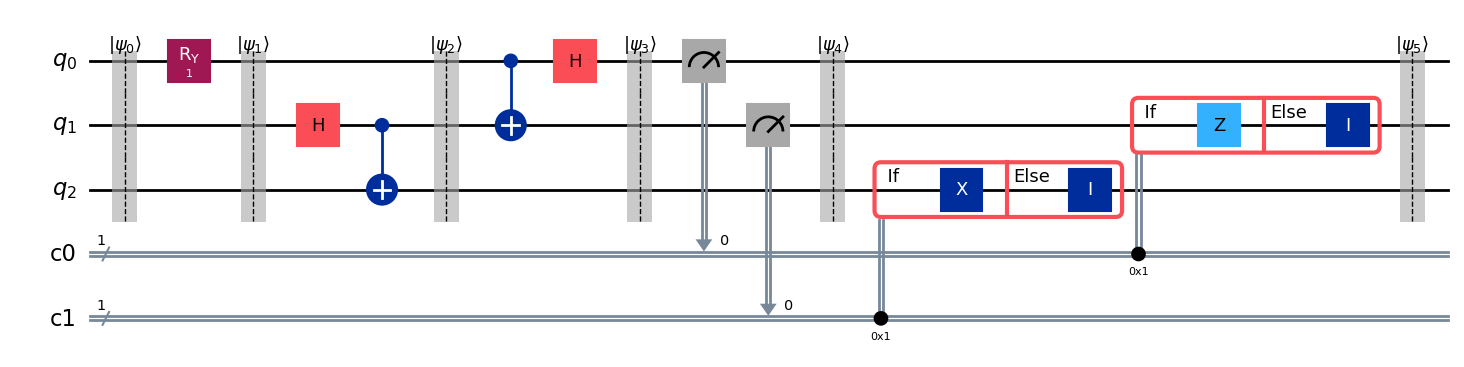

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [3]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import CXGate, CZGate

# 3 qubits: 0 = state to send (Alice's original), 1 = Alice's half of entanglement, 2 = Bob's qubit
# 2 classical bits for Alice's measurements
q = QuantumRegister(3, 'q')
c0 = ClassicalRegister(1, 'c0')  # For Alice's first measurement
c1 = ClassicalRegister(1, 'c1')  # For Alice's second measurement
qc = QuantumCircuit(q, c0, c1)

ket_0 = Statevector(qc)
lab_ket_0 = r"$|\psi_0\rangle$"
qc.barrier(label=lab_ket_0)

# Step 1: Prepare the state to teleport on qubit 0 (Alice)
qc.ry(1.0, q[0])  # Replace 1.0 with any angle/state you want to teleport
ket_1 = Statevector(qc)
lab_ket_1 = r"$|\psi_1\rangle$"
qc.barrier(label=lab_ket_1)

# Step 2: Create Bell pair between qubit 1 (Alice) and qubit 2 (Bob)
qc.h(q[1])
qc.cx(q[1], q[2])
ket_2 = Statevector(qc)
lab_ket_2 = r"$|\psi_2\rangle$"
qc.barrier(label=lab_ket_2)

# Step 3: Entangle Alice's qubit with her half of the Bell pair
qc.cx(q[0], q[1])
qc.h(q[0])
ket_3 = Statevector(qc)
lab_ket_3 = r"$|\psi_3\rangle$"
qc.barrier(label=lab_ket_3)

# Step 4: Measure Alice's qubits (0 and 1) and send results to Bob (classical comm)
qc.measure([q[0], q[1]], [c0[0], c1[0]]) # clbits are sent to Bob
outcomes, ket_4 = ket_3.measure([0, 1]) # consider ideal measurement of statevector separately
lab_ket_4 = r"$|\psi_4\rangle$"
qc.barrier(label=lab_ket_4)
# Step 5: Bob applies corrections based on Alice's results
# qc.cx(1, 2) 
# qc.cz(0, 2)
with qc.if_test((c1, 1)) as else_:
    qc.x(q[2])
with else_:
    qc.id(q[2])
with qc.if_test((c0, 1)) as else_:
    qc.z(q[1])
with else_:
    qc.id(q[1])
ket_5 = ket_4.evolve(CXGate(), [1, 2]).evolve(CZGate(), [0, 2]) # because statevector does not work on circuit with measure
lab_ket_5 = r"$|\psi_5\rangle$"
qc.barrier(label=lab_ket_5)


display(qc.draw('mpl'))

print('Circuit states:')
showState(lab_ket_0, ket_0)
showState(lab_ket_1, ket_1)
showState(lab_ket_2, ket_2)
showState(lab_ket_3, ket_3)

showState(lab_ket_4, ket_4)
showState(lab_ket_5, ket_5)

